<b>AQI Prediction in Delhi</b>

<i>This project focuses on predicting AQI in Delhi based on several factors. 

The dataset was imported from Kaggle.

Multiple regression models were made in order to find the best one.

Dataset link: https://www.kaggle.com/datasets/kunshbhatia/delhi-air-quality-dataset?select=final_dataset.csv
</i>

1.<u>Data preprocessing</u>

<i>Importing modules</i>

- Imported neccessary modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<i>Importing dataset</i>

- Imported dataset

In [2]:
dataset=pd.read_csv(r"C:\Users\Abhijyot Singh Roda\Desktop\Coding Stuff\Python\Projects\Not so random projects\ML Projects\Datasets\FINAL_ITO_DATA.csv")

<i>Information about the dataset</i>

- Got some information about the dataset

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            1461 non-null   int64  
 1   Month           1461 non-null   int64  
 2   Year            1461 non-null   int64  
 3   Holidays_Count  1461 non-null   int64  
 4   Days            1461 non-null   int64  
 5   PM2.5           1461 non-null   float64
 6   PM10            1461 non-null   float64
 7   NO2             1461 non-null   float64
 8   SO2             1461 non-null   float64
 9   CO              1461 non-null   float64
 10  Ozone           1461 non-null   float64
 11  AQI             1461 non-null   int64  
dtypes: float64(6), int64(6)
memory usage: 137.1 KB


<i>First 5 rows</i>

- Head of the dataset

In [4]:
dataset.head()

,Date,Month,Year,Holidays_Count,Days,PM2.5,PM10,NO2,SO2,CO,Ozone,AQI
0,1,1,2021,0,5,363.12,459.14,13.24,21.39,6.75,8.54,432
1,2,1,2021,0,6,260.94,325.94,12.76,20.41,4.45,6.77,418
2,3,1,2021,1,7,117.07,144.22,11.25,12.43,3.13,6.04,306
3,4,1,2021,0,1,80.38,109.95,14.40,11.05,3.00,6.78,138
4,5,1,2021,0,2,60.66,83.23,13.28,11.22,2.75,6.33,129


<i>Last 5 rows</i>

- Tail of the dataset

In [5]:
dataset.tail()

,Date,Month,Year,Holidays_Count,Days,PM2.5,PM10,NO2,SO2,CO,Ozone,AQI
1456,27,12,2024,0,5,154.11,186.61,77.55,17.42,1.39,14.23,357
1457,28,12,2024,0,6,93.38,119.11,68.71,17.14,1.24,14.05,143
1458,29,12,2024,1,7,98.52,128.91,38.12,17.84,0.77,14.63,254
1459,30,12,2024,0,1,94.41,121.45,32.22,13.27,0.96,15.03,178
1460,31,12,2024,0,2,103.02,138.04,41.42,8.64,1.04,13.36,268


<i>Understanding missing values</i>

- Checked if there were any missing values. Although when I consulted Claude, it did say that outliers could be important as they represent real events

In [6]:
print("Number of missing values:")
print(dataset.isnull().sum())

Number of missing values:
Date              0
Month             0
Year              0
Holidays_Count    0
Days              0
PM2.5             0
PM10              0
NO2               0
SO2               0
CO                0
Ozone             0
AQI               0
dtype: int64


<i>Understanding outliers</i>

- Checked if there were any outliers.

In [7]:
numeric_col=dataset.select_dtypes(["int64","float64"]).columns

for col in numeric_col:
    q1=dataset[col].quantile(0.25)
    q3=dataset[col].quantile(0.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    outliers=((dataset[col]<lower)|(dataset[col]>upper))
    print(f"The number of outliers in {col}: {outliers.sum()}")

The number of outliers in Date: 0
The number of outliers in Month: 0
The number of outliers in Year: 0
The number of outliers in Holidays_Count: 277
The number of outliers in Days: 0
The number of outliers in PM2.5: 56
The number of outliers in PM10: 26
The number of outliers in NO2: 114
The number of outliers in SO2: 121
The number of outliers in CO: 79
The number of outliers in Ozone: 45
The number of outliers in AQI: 0


- Box plot

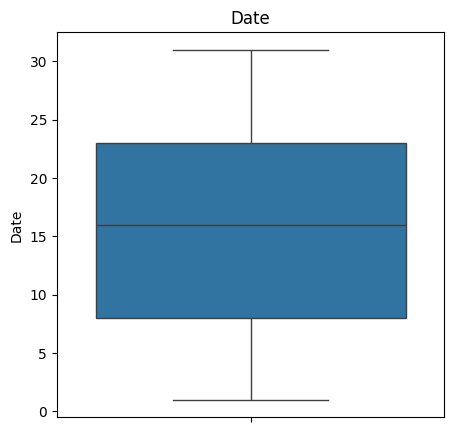

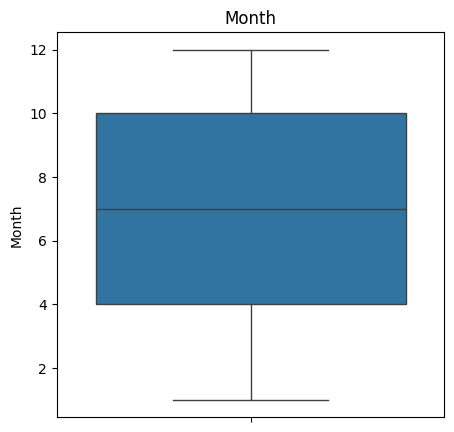

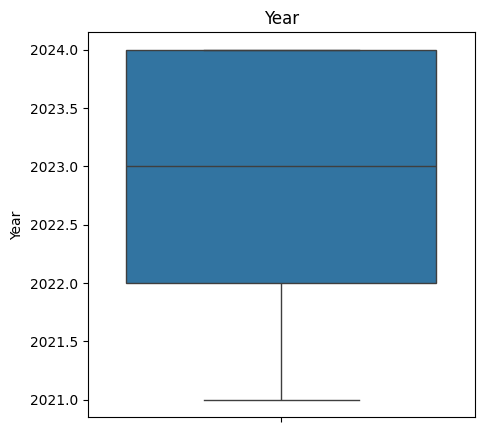

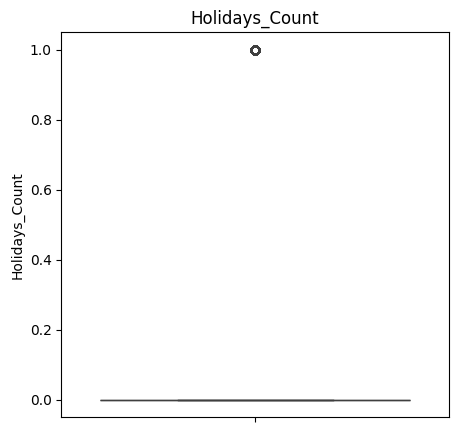

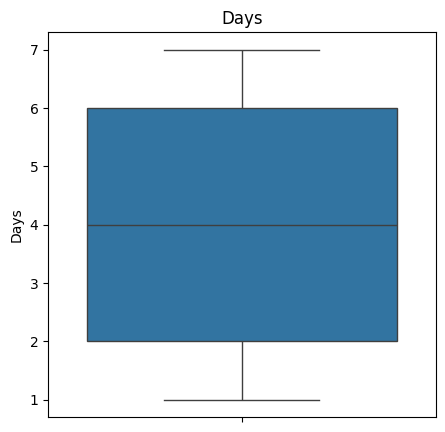

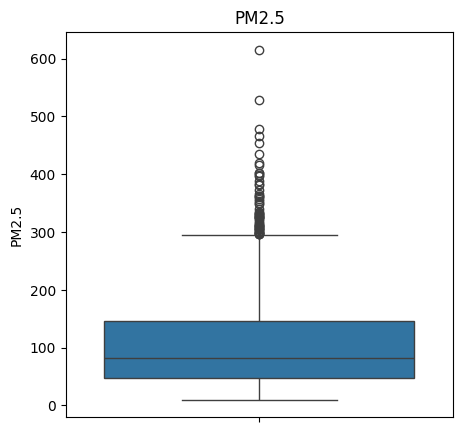

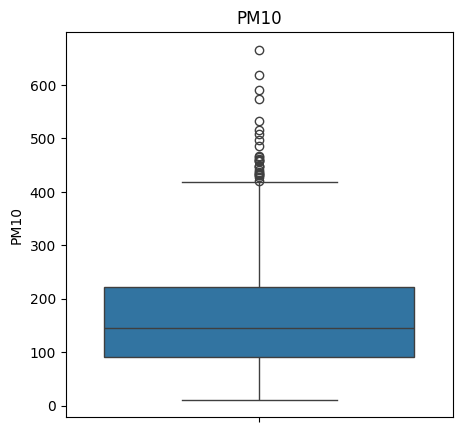

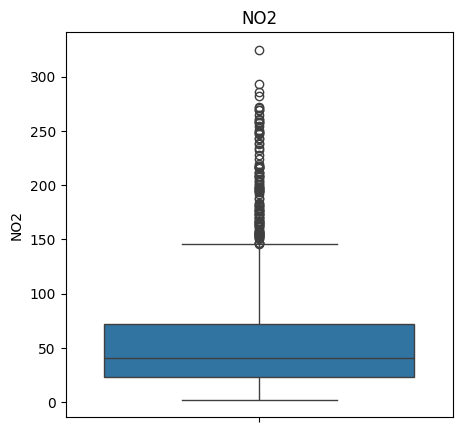

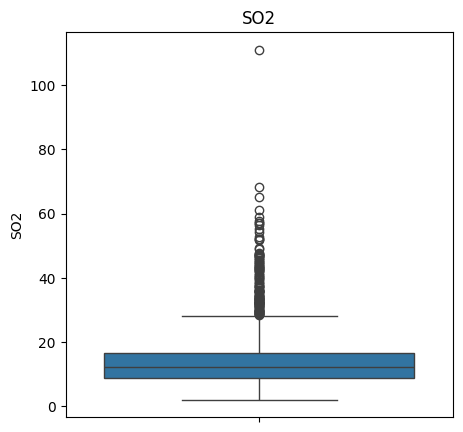

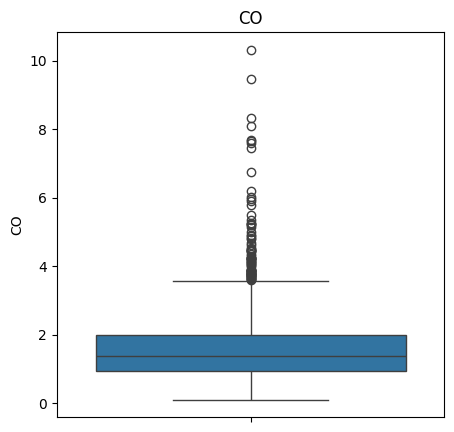

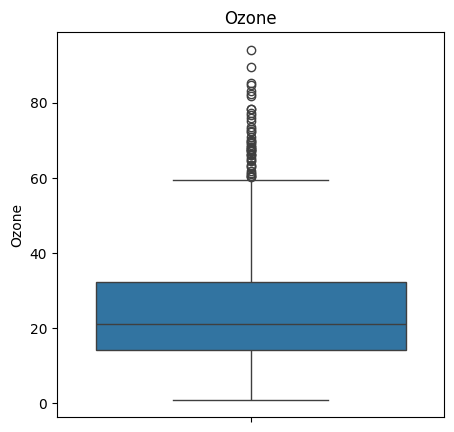

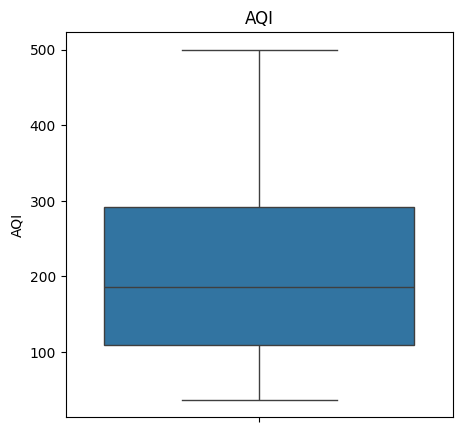

In [8]:
for col in numeric_col:
    plt.figure(figsize=(5,5))
    sns.boxplot(dataset[col])
    plt.title(col)
    plt.show()

<i>Understanding normal distribution of data</i>

- Later half of the dataset is skewed

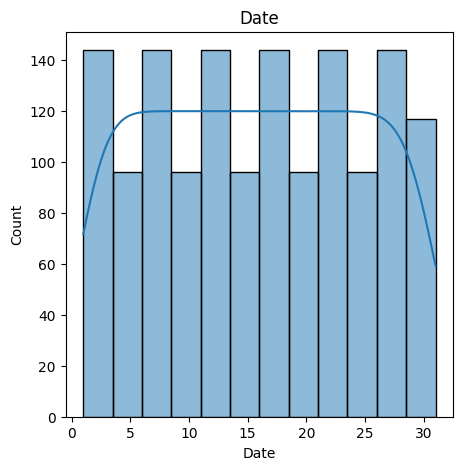

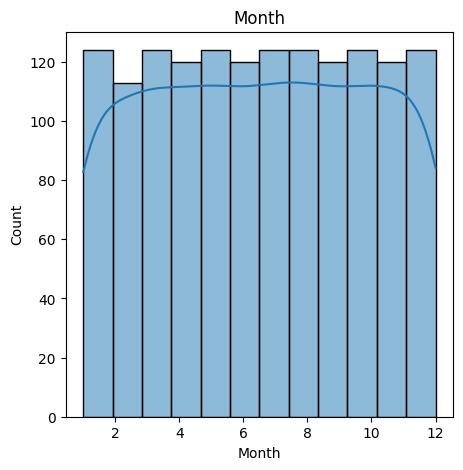

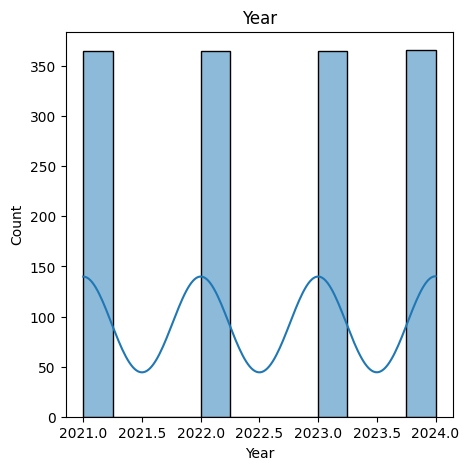

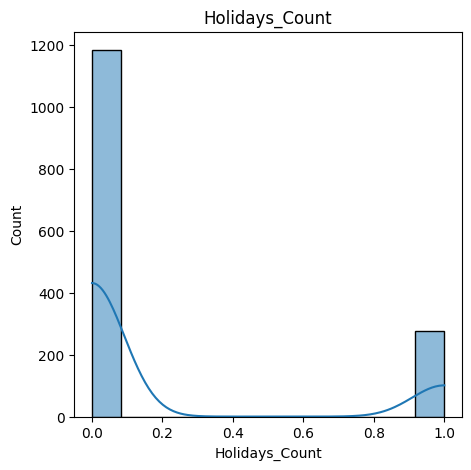

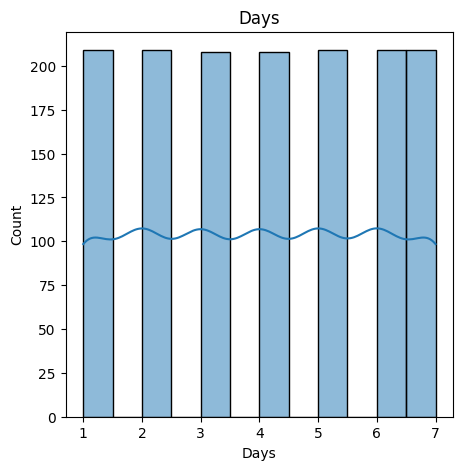

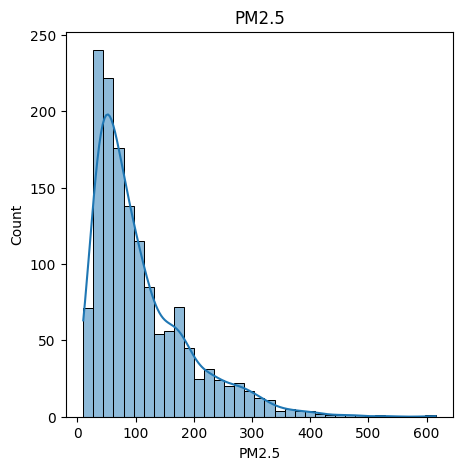

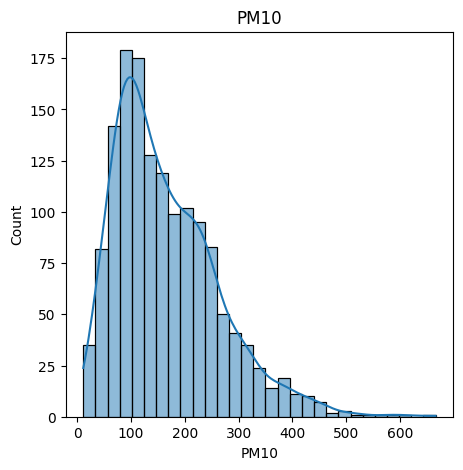

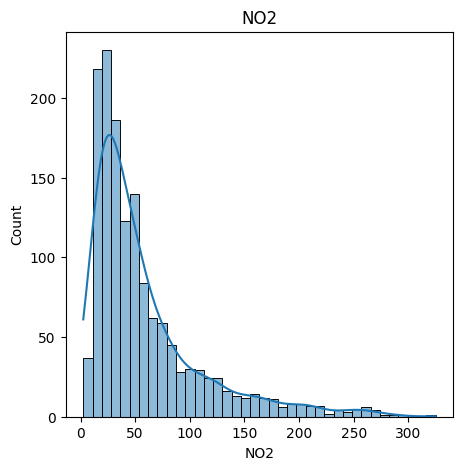

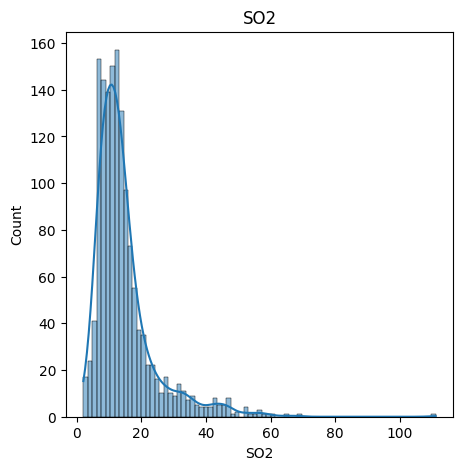

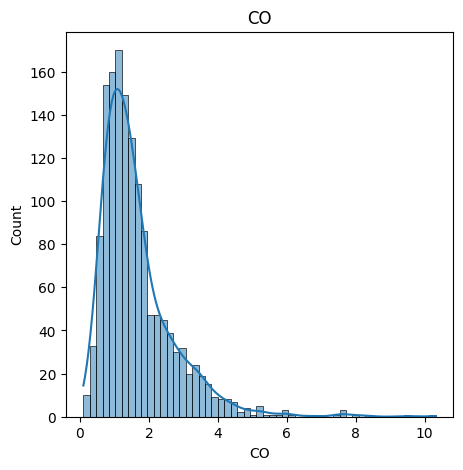

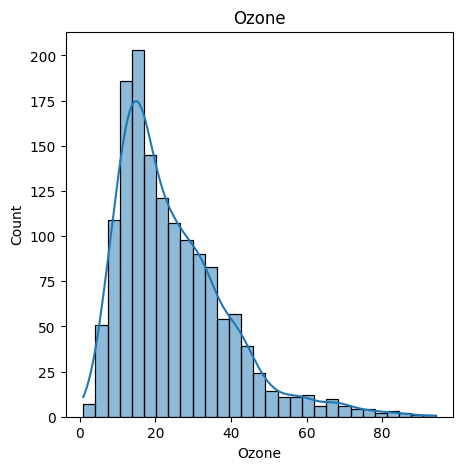

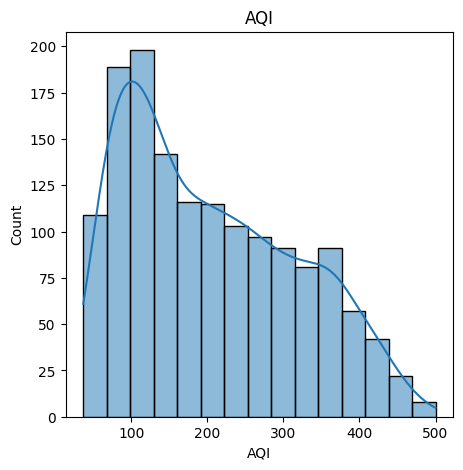

In [9]:
for col in numeric_col:
    plt.figure(figsize=(5,5))
    sns.histplot(dataset[col],kde=True)
    plt.title(col)
    plt.show()

<i>Dropping unnecessary columns using the ANOVA result</i>

- Dropped unnecessary columns based on if p-values > 0.05

In [10]:
import statsmodels.formula.api as sm
from statsmodels.stats.anova import anova_lm

for col in numeric_col:
    if col!="AQI":
        model=sm.ols(f"AQI~Q('{col}')",data=dataset).fit()
        anova=anova_lm(model,typ=2)
        print(f"For {col}, the ANOVA result is:")
        print(anova)

For Date, the ANOVA result is:
                 sum_sq      df        F    PR(>F)
Q('Date')  8.515471e+04     1.0  6.82962  0.009058
Residual   1.819146e+07  1459.0      NaN       NaN
For Month, the ANOVA result is:
                  sum_sq      df         F    PR(>F)
Q('Month')  9.388503e+01     1.0  0.007495  0.931023
Residual    1.827652e+07  1459.0       NaN       NaN
For Year, the ANOVA result is:
                 sum_sq      df         F    PR(>F)
Q('Year')  1.019676e+05     1.0  8.185621  0.004283
Residual   1.817464e+07  1459.0       NaN       NaN
For Holidays_Count, the ANOVA result is:
                           sum_sq      df         F    PR(>F)
Q('Holidays_Count')  6.013318e+02     1.0  0.048005  0.826602
Residual             1.827601e+07  1459.0       NaN       NaN
For Days, the ANOVA result is:
                 sum_sq      df         F    PR(>F)
Q('Days')  3.294227e+03     1.0  0.263022  0.608129
Residual   1.827332e+07  1459.0       NaN       NaN
For PM2.5, the ANOVA res

In [11]:
dataset=dataset.drop(["Date","Holidays_Count","Days"],axis="columns")

- Updated dataset

In [12]:
dataset

,Month,Year,PM2.5,PM10,NO2,SO2,CO,Ozone,AQI
0,1,2021,363.12,459.14,13.24,21.39,6.75,8.54,432
1,1,2021,260.94,325.94,12.76,20.41,4.45,6.77,418
2,1,2021,117.07,144.22,11.25,12.43,3.13,6.04,306
3,1,2021,80.38,109.95,14.40,11.05,3.00,6.78,138
4,1,2021,60.66,83.23,13.28,11.22,2.75,6.33,129
...,...,...,...,...,...,...,...,...,...
1456,12,2024,154.11,186.61,77.55,17.42,1.39,14.23,357
1457,12,2024,93.38,119.11,68.71,17.14,1.24,14.05,143
1458,12,2024,98.52,128.91,38.12,17.84,0.77,14.63,254
1459,12,2024,94.41,121.45,32.22,13.27,0.96,15.03,178


<i>Splitting the dataset into Matrix of Features (X) and Dependent Variable Vector (y)</i>

In [13]:
X=dataset.iloc[:,:-1].values
y=dataset.iloc[:,-1].values

<i>Splitting the dataset into training and test set</i>

In [14]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

<i>Feature scaling</i>

- Used standard scaler because of the "Year" column

In [15]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

2.<u>Model building</u>

<b>a. Multiple Linear Regression</b>

<i>Model building</i>

In [16]:
from sklearn.linear_model import LinearRegression

regression1=LinearRegression()
regression1.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


<i>Predicting the values for the training and the test set</i>

In [17]:
y_pred_train=regression1.predict(X_train)
y_pred_test=regression1.predict(X_test)

print("For the training set:")
np.set_printoptions(precision=2)
print("[Actual_Values Observed_Values]")
print(np.concatenate((y_train.reshape(len(y_train),1),y_pred_train.reshape(len(y_pred_train),1)),axis=1))
print()

print("For the test set:")
np.set_printoptions(precision=2)
print("[Actual_Values Observed_Values]")
print(np.concatenate((y_test.reshape(len(y_test),1),y_pred_test.reshape(len(y_pred_test),1)),axis=1))

For the training set:
[Actual_Values Observed_Values]
[[ 64.    98.08]
 [140.   167.62]
 [136.   153.04]
 ...
 [121.   136.86]
 [106.   121.09]
 [233.   187.67]]

For the test set:
[Actual_Values Observed_Values]
[[124.   123.04]
 [229.   251.07]
 [148.   169.  ]
 [ 99.   132.59]
 [229.   249.56]
 [403.   433.21]
 [335.   296.95]
 [160.   172.45]
 [259.   276.55]
 [340.   303.72]
 [ 82.    90.06]
 [422.   480.78]
 [135.   114.17]
 [ 77.    88.79]
 [243.   196.3 ]
 [ 56.   121.68]
 [ 73.    82.11]
 [187.   155.81]
 [362.   403.65]
 [281.   280.54]
 [172.   158.86]
 [136.   159.96]
 [305.   248.66]
 [ 77.    97.01]
 [100.   116.68]
 [ 87.   120.91]
 [102.   103.17]
 [346.   265.17]
 [174.   162.47]
 [122.   139.43]
 [314.   205.7 ]
 [377.   387.69]
 [325.   229.58]
 [129.   145.77]
 [304.   254.83]
 [ 69.   112.92]
 [345.   252.73]
 [257.   180.34]
 [340.   260.21]
 [259.   223.7 ]
 [189.   198.21]
 [261.   258.48]
 [300.   265.98]
 [418.   404.81]
 [130.   127.65]
 [419.   384.64]
 [309

<i>Graphical Representation</i>

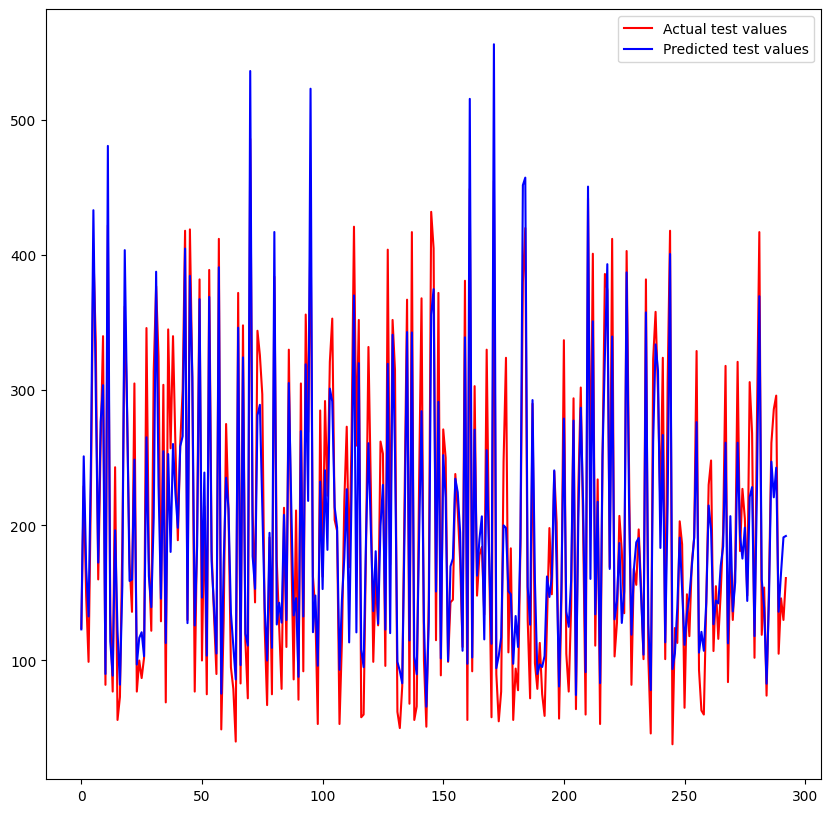

In [42]:
plt.figure(figsize=(10,10))
plt.plot(y_test,color="red",label="Actual test values")
plt.plot(y_pred_test,color="blue",label="Predicted test values")
plt.legend()
plt.show()

<i>Accuracy of the model</i>

In [18]:
from sklearn.metrics import r2_score

print(f"R2-score for the training set is: {r2_score(y_train,y_pred_train)*100}")

print(f"R2-score for the test set is: {r2_score(y_test,y_pred_test)*100}")

R2-score for the training set is: 85.11986444216826
R2-score for the test set is: 87.37280341057236


<b>b. Polynomial Linear Regression</b>

<i>Making polynomial features</i>

In [19]:
from sklearn.preprocessing import PolynomialFeatures

poly_fea=PolynomialFeatures(degree=2)
X_train_poly=poly_fea.fit_transform(X_train)
X_test_poly=poly_fea.transform(X_test)

<i>Model building</i>

In [20]:
from sklearn.linear_model import LinearRegression

regression2=LinearRegression()
regression2.fit(X_train_poly,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


<i>Predicting the values for the training and the test set</i>

In [21]:
y_pred_train2=regression2.predict(X_train_poly)
y_pred_test2=regression2.predict(X_test_poly)

print("For the training set:")
np.set_printoptions(precision=2)
print("[Actual_Values Observed_Values]")
print(np.concatenate((y_train.reshape(len(y_train),1),y_pred_train2.reshape(len(y_pred_train2),1)),axis=1))
print()

print("For the test set:")
np.set_printoptions(precision=2)
print("[Actual_Values Observed_Values]")
print(np.concatenate((y_test.reshape(len(y_test),1),y_pred_test2.reshape(len(y_pred_test2),1)),axis=1))

For the training set:
[Actual_Values Observed_Values]
[[ 64.    72.8 ]
 [140.   149.29]
 [136.   143.29]
 ...
 [121.   135.55]
 [106.    97.54]
 [233.   217.37]]

For the test set:
[Actual_Values Observed_Values]
[[124.    99.5 ]
 [229.   264.76]
 [148.   166.66]
 [ 99.   126.2 ]
 [229.   258.44]
 [403.   421.3 ]
 [335.   331.35]
 [160.   169.42]
 [259.   286.33]
 [340.   335.31]
 [ 82.    74.03]
 [422.   452.29]
 [135.   100.01]
 [ 77.    45.49]
 [243.   214.03]
 [ 56.   103.26]
 [ 73.    59.3 ]
 [187.   152.15]
 [362.   399.96]
 [281.   295.67]
 [172.   146.75]
 [136.   174.45]
 [305.   273.4 ]
 [ 77.    88.3 ]
 [100.    88.5 ]
 [ 87.   128.39]
 [102.    82.21]
 [346.   319.19]
 [174.   175.82]
 [122.   136.19]
 [314.   248.18]
 [377.   374.04]
 [325.   285.23]
 [129.   135.44]
 [304.   284.68]
 [ 69.    93.64]
 [345.   289.12]
 [257.   191.29]
 [340.   289.64]
 [259.   243.46]
 [189.   221.83]
 [261.   273.77]
 [300.   305.28]
 [418.   416.22]
 [130.   106.68]
 [419.   422.32]
 [309

<i>Accuracy of the model</i>

In [22]:
from sklearn.metrics import r2_score

print(f"R2-score for the training set is: {r2_score(y_train,y_pred_train2)*100}")

print(f"R2-score for the test set is: {r2_score(y_test,y_pred_test2)*100}")

R2-score for the training set is: 93.0471327092343
R2-score for the test set is: 93.31943149523077


<b>c. Support Vector Regression</b>

<i>Model building</i>

In [23]:
from sklearn.svm import SVR

regression3=SVR(kernel="rbf")
regression3.fit(X_train,y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


<i>Predicting the values for the training and the test set</i>

In [24]:
y_pred_train3=regression3.predict(X_train)
y_pred_test3=regression3.predict(X_test)

print("For the training set:")
np.set_printoptions(precision=2)
print("[Actual_Values Observed_Values]")
print(np.concatenate((y_train.reshape(len(y_train),1),y_pred_train3.reshape(len(y_pred_train3),1)),axis=1))
print()

print("For the test set:")
np.set_printoptions(precision=2)
print("[Actual_Values Observed_Values]")
print(np.concatenate((y_test.reshape(len(y_test),1),y_pred_test3.reshape(len(y_pred_test3),1)),axis=1))

For the training set:
[Actual_Values Observed_Values]
[[ 64.   108.67]
 [140.   196.61]
 [136.   144.7 ]
 ...
 [121.   155.87]
 [106.   136.32]
 [233.   171.95]]

For the test set:
[Actual_Values Observed_Values]
[[124.   110.54]
 [229.   254.49]
 [148.   166.55]
 [ 99.   144.76]
 [229.   252.02]
 [403.   304.62]
 [335.   265.76]
 [160.   151.98]
 [259.   251.62]
 [340.   281.99]
 [ 82.   117.22]
 [422.   290.54]
 [135.   143.72]
 [ 77.    99.79]
 [243.   224.5 ]
 [ 56.   176.2 ]
 [ 73.   111.15]
 [187.   189.01]
 [362.   281.11]
 [281.   269.85]
 [172.   174.09]
 [136.   165.08]
 [305.   248.63]
 [ 77.   171.99]
 [100.   117.52]
 [ 87.   179.63]
 [102.   121.12]
 [346.   246.4 ]
 [174.   170.27]
 [122.   125.57]
 [314.   186.61]
 [377.   279.81]
 [325.   230.97]
 [129.   195.39]
 [304.   244.67]
 [ 69.   112.95]
 [345.   245.45]
 [257.   159.05]
 [340.   243.06]
 [259.   232.73]
 [189.   215.32]
 [261.   249.31]
 [300.   258.3 ]
 [418.   295.56]
 [130.   136.3 ]
 [419.   242.51]
 [309

<i>Accuracy of the model</i>

In [25]:
from sklearn.metrics import r2_score

print(f"R2-score for the training set is: {r2_score(y_train,y_pred_train3)*100}")

print(f"R2-score for the test set is: {r2_score(y_test,y_pred_test3)*100}")

R2-score for the training set is: 66.18902650622265
R2-score for the test set is: 66.00473003551963


<b>d. Decision Tree Regression</b>

<i>Model building</i>

In [26]:
from sklearn.tree import DecisionTreeRegressor

regression4=DecisionTreeRegressor(max_depth=5)
regression4.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


<i>Predicting the values for the training and the test set</i>

In [27]:
y_pred_train4=regression4.predict(X_train)
y_pred_test4=regression4.predict(X_test)

print("For the training set:")
np.set_printoptions(precision=2)
print("[Actual_Values Observed_Values]")
print(np.concatenate((y_train.reshape(len(y_train),1),y_pred_train4.reshape(len(y_pred_train4),1)),axis=1))
print()

print("For the test set:")
np.set_printoptions(precision=2)
print("[Actual_Values Observed_Values]")
print(np.concatenate((y_test.reshape(len(y_test),1),y_pred_test4.reshape(len(y_pred_test4),1)),axis=1))

For the training set:
[Actual_Values Observed_Values]
[[ 64.    74.73]
 [140.   148.12]
 [136.   124.64]
 ...
 [121.   124.64]
 [106.   124.64]
 [233.   247.02]]

For the test set:
[Actual_Values Observed_Values]
[[124.   124.64]
 [229.   247.02]
 [148.   148.12]
 [ 99.   100.69]
 [229.   247.02]
 [403.   419.27]
 [335.   322.09]
 [160.   188.02]
 [259.   322.09]
 [340.   322.09]
 [ 82.    74.73]
 [422.   419.27]
 [135.    74.73]
 [ 77.    74.73]
 [243.   202.56]
 [ 56.    74.73]
 [ 73.    74.73]
 [187.   124.64]
 [362.   388.49]
 [281.   322.09]
 [172.   124.64]
 [136.   148.12]
 [305.   273.92]
 [ 77.    74.73]
 [100.    74.73]
 [ 87.    74.73]
 [102.    74.73]
 [346.   322.09]
 [174.   148.12]
 [122.   124.64]
 [314.   273.92]
 [377.   362.77]
 [325.   273.92]
 [129.   100.69]
 [304.   322.09]
 [ 69.    74.73]
 [345.   322.09]
 [257.   188.02]
 [340.   322.09]
 [259.   247.02]
 [189.   245.29]
 [261.   273.92]
 [300.   322.09]
 [418.   388.49]
 [130.   124.64]
 [419.   388.49]
 [309

<i>Accuracy of the model</i>

In [28]:
from sklearn.metrics import r2_score

print(f"R2-score for the training set is: {r2_score(y_train,y_pred_train4)*100}")

print(f"R2-score for the test set is: {r2_score(y_test,y_pred_test4)*100}")

R2-score for the training set is: 94.00589246960041
R2-score for the test set is: 93.15962629410399


<i>Plotting decision tree</i>

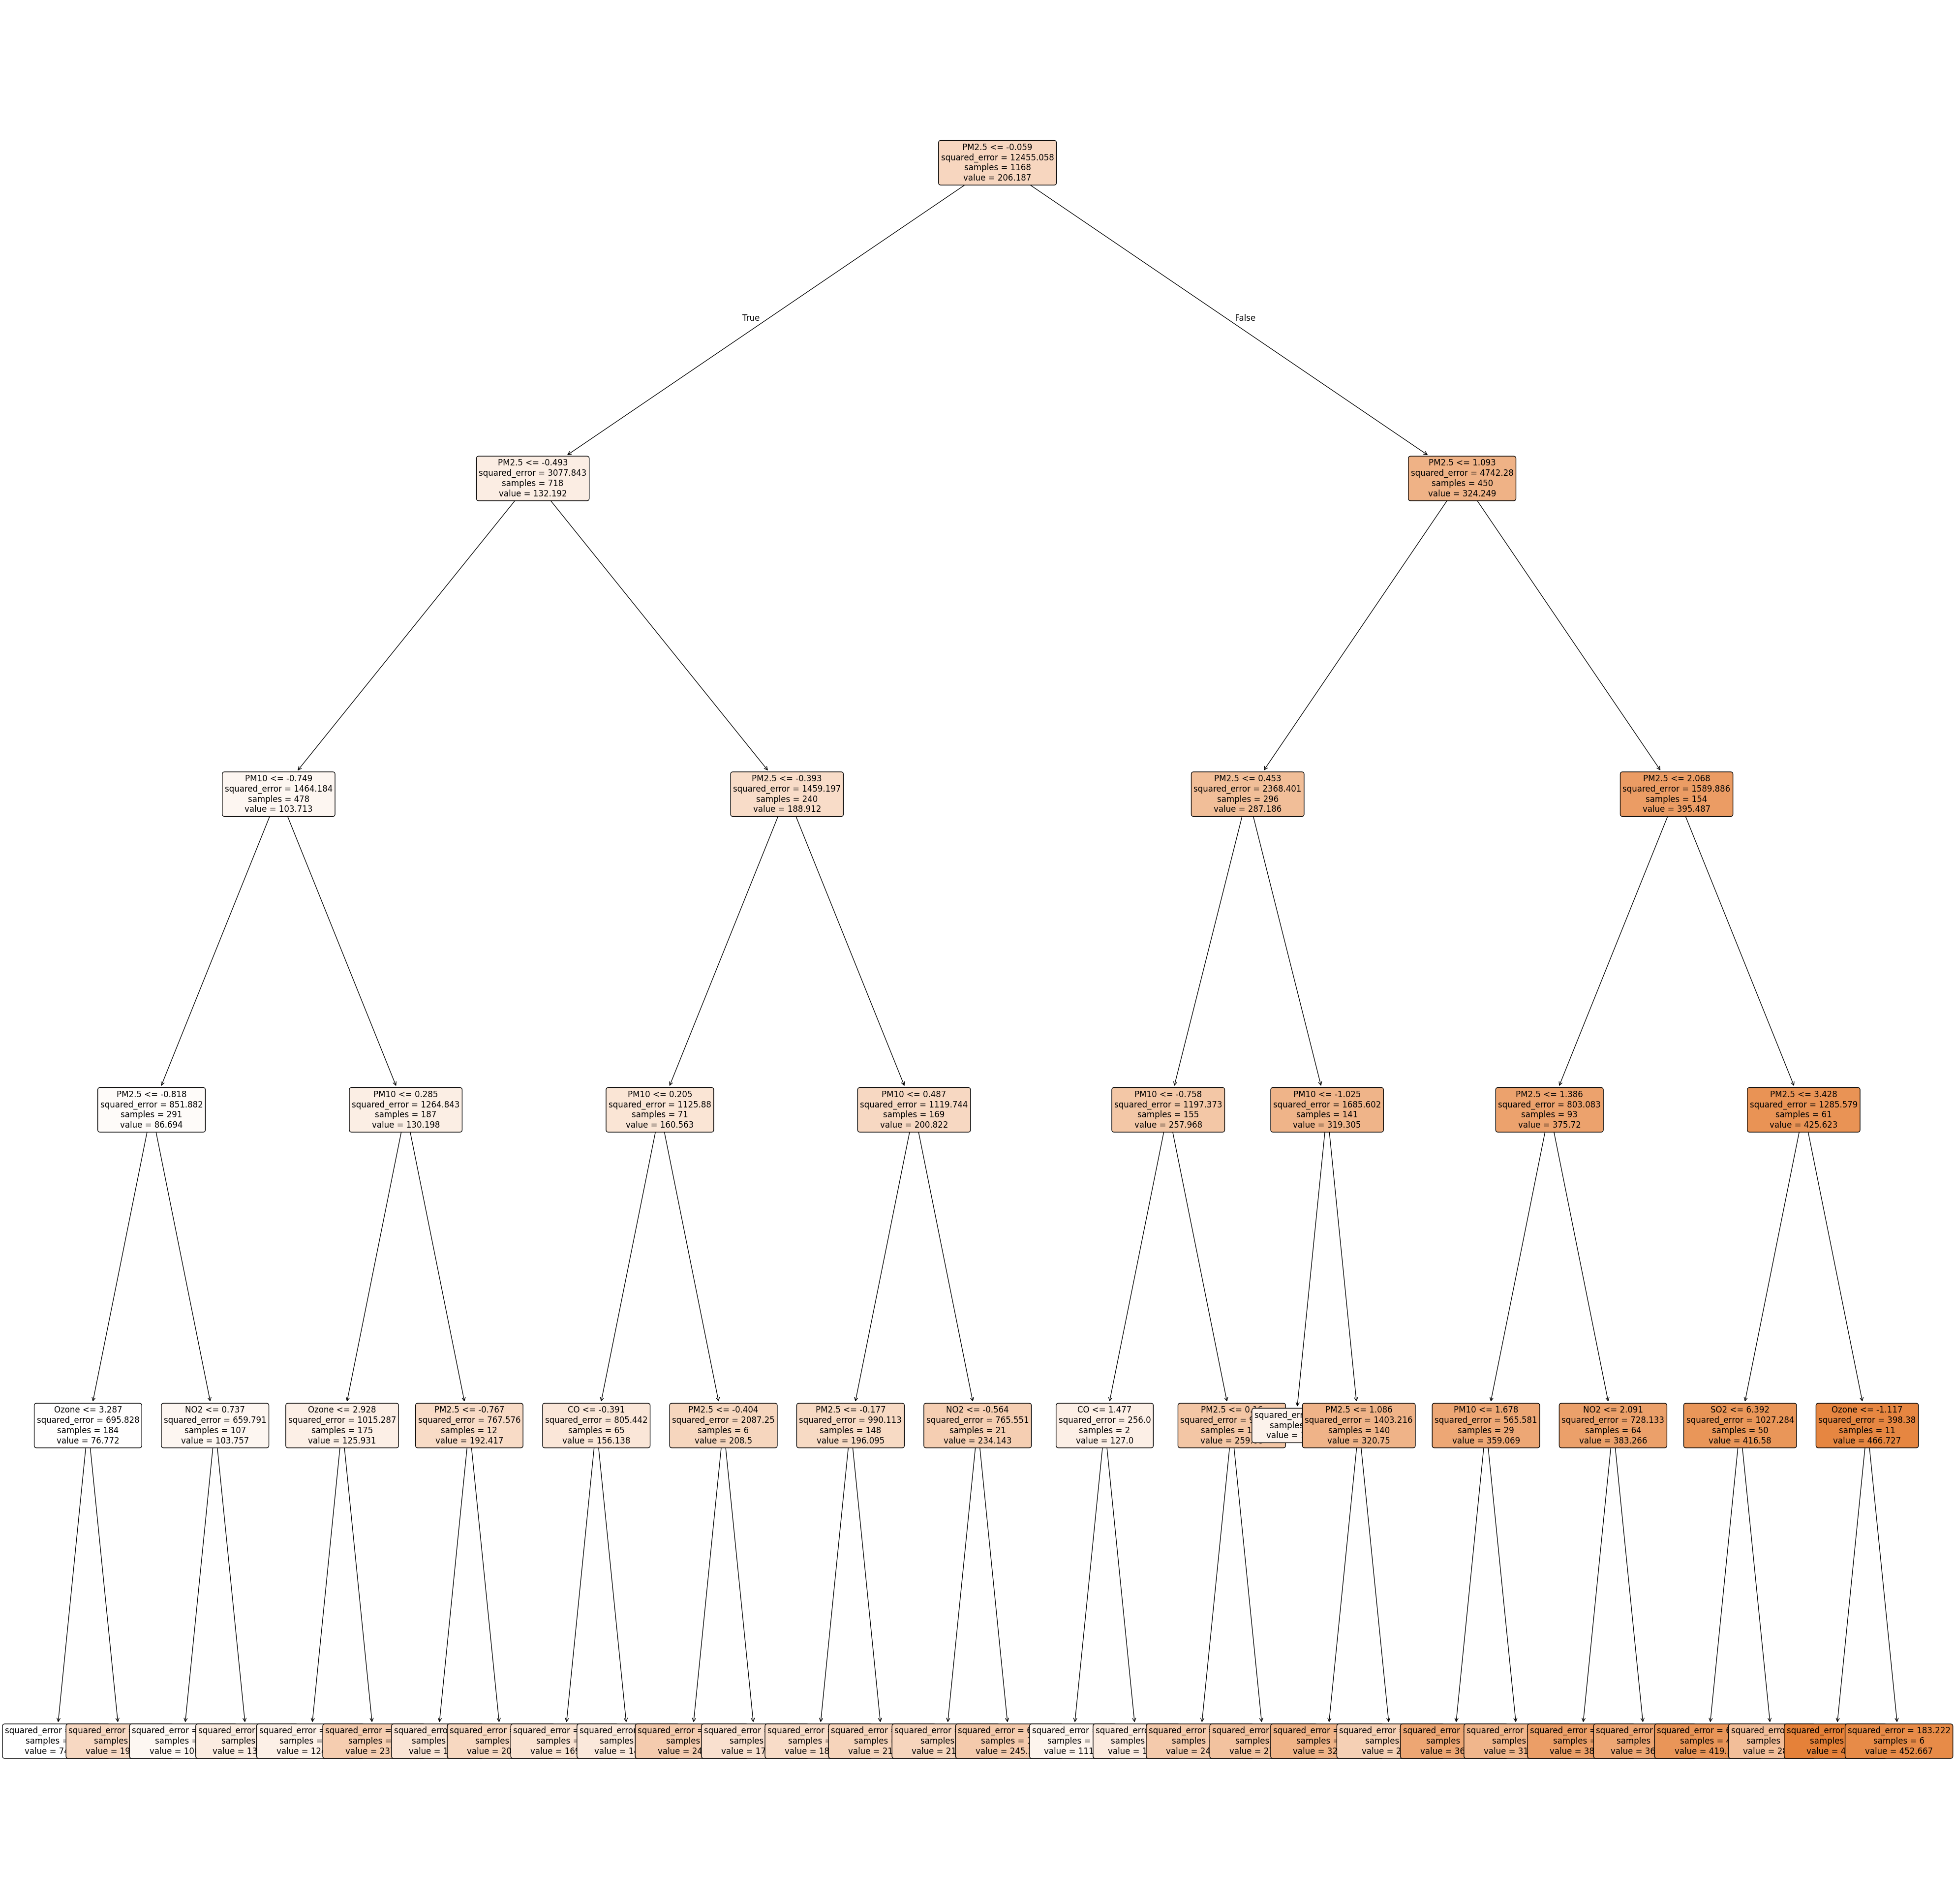

In [29]:
from sklearn.tree import plot_tree

plt.figure(figsize=(50,50))
plot_tree(
    regression4,
    feature_names=["Month","Year","PM2.5","PM10","NO2","SO2","CO","Ozone"],
    class_names=["AQI"],
    filled=True,
    rounded=True,
    fontsize=12
)

plt.show()

<b>e. Random Forest Regression</b>

<i>Model building</i>

In [30]:
from sklearn.ensemble import RandomForestRegressor

regression5=RandomForestRegressor(n_estimators=500)
regression5.fit(X_train,y_train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


<i>Predicting the values for the training and the test set</i>

In [31]:
y_pred_train5=regression5.predict(X_train)
y_pred_test5=regression5.predict(X_test)

print("For the training set:")
np.set_printoptions(precision=2)
print("[Actual_Values Observed_Values]")
print(np.concatenate((y_train.reshape(len(y_train),1),y_pred_train5.reshape(len(y_pred_train5),1)),axis=1))
print()

print("For the test set:")
np.set_printoptions(precision=2)
print("[Actual_Values Observed_Values]")
print(np.concatenate((y_test.reshape(len(y_test),1),y_pred_test5.reshape(len(y_pred_test5),1)),axis=1))

For the training set:
[Actual_Values Observed_Values]
[[ 64.    62.81]
 [140.   144.74]
 [136.   135.81]
 ...
 [121.   120.08]
 [106.   105.45]
 [233.   239.56]]

For the test set:
[Actual_Values Observed_Values]
[[124.   111.89]
 [229.   246.27]
 [148.   155.62]
 [ 99.   119.5 ]
 [229.   241.25]
 [403.   410.88]
 [335.   322.53]
 [160.   162.04]
 [259.   292.16]
 [340.   322.42]
 [ 82.    74.47]
 [422.   433.8 ]
 [135.   111.75]
 [ 77.    63.21]
 [243.   209.62]
 [ 56.    91.86]
 [ 73.    71.71]
 [187.   157.62]
 [362.   391.94]
 [281.   294.11]
 [172.   133.58]
 [136.   159.63]
 [305.   280.39]
 [ 77.    77.72]
 [100.    79.62]
 [ 87.   104.23]
 [102.    81.69]
 [346.   318.75]
 [174.   158.54]
 [122.   115.17]
 [314.   290.63]
 [377.   368.47]
 [325.   285.04]
 [129.   113.17]
 [304.   290.29]
 [ 69.    77.05]
 [345.   293.25]
 [257.   196.29]
 [340.   284.44]
 [259.   244.61]
 [189.   231.01]
 [261.   269.23]
 [300.   300.51]
 [418.   405.39]
 [130.   101.86]
 [419.   388.58]
 [309

<i>Accuracy of the model</i>

In [32]:
from sklearn.metrics import r2_score

print(f"R2-score for the training set is: {r2_score(y_train,y_pred_train5)*100}")

print(f"R2-score for the test set is: {r2_score(y_test,y_pred_test5)*100}")

R2-score for the training set is: 98.97991443608196
R2-score for the test set is: 94.79445801397344


3.<u>Result</u>

- Model Performance Comparison

| Model | Training R² (%) | Testing R² (%) |
|---|---:|---:|
| Linear Regression | 85.12 | 87.37 |
| Polynomial Regression (Degree 2) | 93.05 | 93.32 |
| Support Vector Regression (RBF) | 66.19 | 66.00 |
| Decision Tree Regression | 94.01 | 93.13 |
| Random Forest Regression | 99.00 | **94.80** |

4.<u>Model deployment</u>

- Deploying "Random Forest Regressor" model for future use

In [ ]:
import pickle as pk

with open(r"Random_Forest.pk","wb") as file:
    pk.dump(regression5,file)